In [ ]:
# === [TFM_newcodes] redireccion de figuras a la carpeta ./figures/ ===
# Celda anadida automaticamente: cualquier figura guardada con un nombre
# de fichero simple (sin carpeta) se guarda dentro de ./figures/.
# Las rutas que ya incluyen una carpeta (p.ej. 'figures/...') se respetan.
import os as _os
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure
_os.makedirs('figures', exist_ok=True)
_os.makedirs('Data', exist_ok=True)  # CSVs de resultados circadianos
def _fig_redirect(fname):
    try:
        p = _os.fspath(fname)
    except TypeError:
        return fname  # objeto tipo fichero/buffer: no tocar
    if _os.path.dirname(p) == '':
        p = _os.path.join('figures', p)
    d = _os.path.dirname(p)
    if d:
        _os.makedirs(d, exist_ok=True)
    return p
if not getattr(_plt.savefig, '_tfm_patched', False):
    _orig_plt_savefig = _plt.savefig
    _orig_fig_savefig = _Figure.savefig
    def _plt_savefig(fname, *a, **k):
        return _orig_plt_savefig(_fig_redirect(fname), *a, **k)
    _plt_savefig._tfm_patched = True
    def _fig_savefig(self, fname, *a, **k):
        return _orig_fig_savefig(self, _fig_redirect(fname), *a, **k)
    _plt.savefig = _plt_savefig
    _Figure.savefig = _fig_savefig
savefig = _plt.savefig  # por si se usa savefig(...) directamente


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import powerlaw, truncnorm, ks_2samp
import powerlaw
import random
import ast, os
# Simple trapezoid integration for NumPy 2.0+ compatibility
def trapz(y, x):
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2)


In [36]:
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

active_users_df = pd.read_csv("Data/circadian_cycles_all_results.csv")
active_users_reshuffling_df = pd.read_csv("Data/circadian_cycles_all_reshuffle_results.csv")



In [37]:
# Load reshuffled SA results + p-values from CSV (skip recomputation if available)
RESHUFFLE_CSV = 'Data/circadian_cycles_vagarenfe_2024_reshuffle_results.csv'

if os.path.exists(RESHUFFLE_CSV):
    saved_r = pd.read_csv(RESHUFFLE_CSV)
    reshuffle_model_results = {}
    reshuffle_pvalues       = {}
    for _, row in saved_r.iterrows():
        uid = int(row['user_id'])
        reshuffle_model_results[uid] = {
            'shuf_iets_h': np.array([]),          # not stored; recompute from reshuffle_results if needed
            'sim_events':  np.array([]),
            'rho_a':  float(row['rho_a']),
            'Nw':     float(row['Nw']),
            'pd_t':   _parse_array(row['pd_t']),
            'pw_t':   _parse_array(row['pw_t']),
            'p_Na':   _parse_array(row['p_Na']),
            'A_best': float(row['A_best']),
            'A_fit':  float(row['A_fit']),
        }
        reshuffle_pvalues[uid] = (
            float(row['p_value_reshuffle'])
            if 'p_value_reshuffle' in row and pd.notna(row['p_value_reshuffle'])
            else np.nan
        )
    print(f"Loaded {len(reshuffle_model_results)} reshuffled results from {RESHUFFLE_CSV} — skipping SA and Monte Carlo on reshuffle.")
else:
    reshuffle_model_results = None   # triggers SA below
    reshuffle_pvalues       = {}
    print(f"{RESHUFFLE_CSV} not found — will run SA and Monte Carlo on reshuffled data.")

Loaded 30 reshuffled results from circadian_cycles_vagarenfe_2024_reshuffle_results.csv — skipping SA and Monte Carlo on reshuffle.


In [38]:
# Gather users with more than 40 messages of the groupchat.
user_message_counts = df['sender_id'].value_counts()
active_users = user_message_counts[user_message_counts > 40].index.tolist()
active_users_message_counts = user_message_counts[user_message_counts > 40]
# Print the number of active users.
print(f"Number of active users (more than 40 messages): {len(active_users)}")


Number of active users (more than 40 messages): 67


In [39]:
df = df.sort_values('date') # Sort messages by date to calculate inter-event times correctly.

# Calcular inter-event times en segundos
df['iet'] = df['date'].diff().dt.total_seconds()



In [40]:


def _parse_array(s):
    """Parse a numpy-array repr string back to a float array."""
    cleaned = s.strip().replace('\n', ' ')
    # Handle both '[0.1 0.2 ...]' and '[0.1, 0.2, ...]' formats
    if ',' not in cleaned:
        cleaned = cleaned.replace('[', '').replace(']', '')
        return np.array([float(x) for x in cleaned.split()])
    return np.array(ast.literal_eval(cleaned))

RESULTS_CSV = 'Data/circadian_cycles_all_results.csv'

if os.path.exists(RESULTS_CSV):
    saved = pd.read_csv(RESULTS_CSV)
    parameters_users = {}
    pvalues_users = {}
    pvalues_users    = {}
    for _, row in saved.iterrows():
        uid = int(row['user_id'])
        parameters_users[uid] = {
            'rho_a': float(row['rho_a']),
            'Nw':    float(row['Nw']),
            'pd_t':  _parse_array(row['pd_t']),
            'pw_t':  _parse_array(row['pw_t']),
            'p_Na':  _parse_array(row['p_Na']),
            'A_best': float(row['A_best']),
        }
        #pvalues_users[uid] = float(row['p_value']) if pd.notna(row['p_value']) else np.nan
    print(f"Loaded {len(parameters_users)} users from {RESULTS_CSV} — skipping SA and Monte Carlo.")
else:
    parameters_users = None  # will be populated by the SA cell below
    print(f"{RESULTS_CSV} not found — will run SA and Monte Carlo from scratch.")


Loaded 67 users from circadian_cycles_all_results.csv — skipping SA and Monte Carlo.


In [41]:
# Load reshuffled SA results + p-values from CSV (skip recomputation if available)
RESHUFFLE_CSV = 'Data/circadian_cycles_all_reshuffle_results.csv'

if os.path.exists(RESHUFFLE_CSV):
    saved_r = pd.read_csv(RESHUFFLE_CSV)
    reshuffle_model_results = {}
    reshuffle_pvalues       = {}
    for _, row in saved_r.iterrows():
        uid = int(row['user_id'])
        reshuffle_model_results[uid] = {
            'shuf_iets_h': np.array([]),          # not stored; recompute from reshuffle_results if needed
            'sim_events':  np.array([]),
            'rho_a':  float(row['rho_a']),
            'Nw':     float(row['Nw']),
            'pd_t':   _parse_array(row['pd_t']),
            'pw_t':   _parse_array(row['pw_t']),
            'p_Na':   _parse_array(row['p_Na']),
            'A_best': float(row['A_best']),
            'A_fit':  float(row['A_fit']),
        }
        reshuffle_pvalues[uid] = (
            float(row['p_value_reshuffle'])
            if 'p_value_reshuffle' in row and pd.notna(row['p_value_reshuffle'])
            else np.nan
        )
    print(f"Loaded {len(reshuffle_model_results)} reshuffled results from {RESHUFFLE_CSV} — skipping SA and Monte Carlo on reshuffle.")
else:
    reshuffle_model_results = None   # triggers SA below
    reshuffle_pvalues       = {}
    print(f"{RESHUFFLE_CSV} not found — will run SA and Monte Carlo on reshuffled data.")


Loaded 66 reshuffled results from circadian_cycles_all_reshuffle_results.csv — skipping SA and Monte Carlo on reshuffle.


In [42]:
# Remove users with less than MIN_DAYS of activity from the reshuffled results
MIN_DAYS = 8

removed = []
for uid in list(reshuffle_model_results.keys()):
    user_dates = pd.to_datetime(
        df.loc[df['sender_id'] == uid, 'date'], errors='coerce'
    ).dropna()
    activity_days = (user_dates.max() - user_dates.min()).days if len(user_dates) >= 2 else 0
    if activity_days < MIN_DAYS:
        reshuffle_model_results.pop(uid)
        reshuffle_pvalues.pop(uid, None)
        removed.append(uid)

print(f"Removed {len(removed)} users with < {MIN_DAYS} days of activity from reshuffled results.")
print(f"Remaining reshuffled users: {len(reshuffle_model_results)}")


Removed 26 users with < 8 days of activity from reshuffled results.
Remaining reshuffled users: 40


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Pooled 5,647 original IETs from 40 users


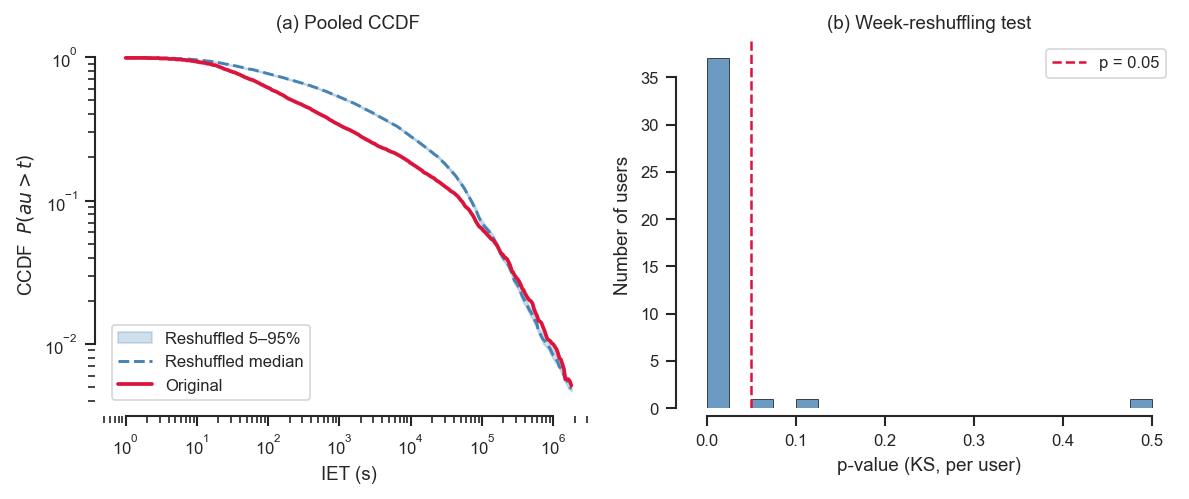


KS test (pooled original vs pooled reshuffled):
  D = 0.2007,  p = 3.5795e-182

Per-user week-reshuffling test:
  Users rejected at p<0.05: 37/40 (92.5%)
  Median KS statistic: 0.2343
Saved figures/paper_ccdf_orig_vs_reshuffle.pdf


In [43]:
# ── CCDF comparison: original IETs vs week-reshuffled IETs ────────────────────
# For each user in reshuffle_model_results, compute original IETs and one
# reshuffled sequence, then compare the pooled CCDFs + KS test.
from scipy.stats import ks_2samp
import seaborn as sns, matplotlib as mpl, matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

N_SHUFFLES = 200
rng = np.random.default_rng(42)

def _week_reshuffle_once(dates, rng):
    dates = pd.Series(dates).dropna().sort_values().reset_index(drop=True)
    if len(dates) < 10:
        return None
    first_monday = dates.iloc[0] - pd.Timedelta(days=dates.iloc[0].weekday())
    week_num = ((dates - first_monday).dt.total_seconds() // (7*86400)).astype(int).values
    weekday  = dates.dt.weekday.values
    tod_sec  = (dates.dt.hour*3600 + dates.dt.minute*60 + dates.dt.second).values
    perm     = rng.permutation(week_num)
    new_ts   = np.sort(perm * 7*86400 + weekday*86400 + tod_sec).astype(float)
    iets     = np.diff(new_ts)
    return iets[iets > 0]

# ── Pool IETs across all users ────────────────────────────────────────────────
all_orig_iets = []
all_shuf_iets_list = [[] for _ in range(N_SHUFFLES)]
ks_per_user   = {}

for uid in reshuffle_model_results:
    user_dates = pd.to_datetime(
        df.loc[df['sender_id'] == uid, 'date'], errors='coerce'
    ).dropna().sort_values()
    if len(user_dates) < 10:
        continue

    # Original IETs in seconds
    ts   = user_dates.values.astype('int64') / 1e9
    orig = np.diff(np.sort(ts))
    orig = orig[orig > 0]
    all_orig_iets.extend(orig.tolist())

    # N_SHUFFLES reshuffled sequences
    shuf_iets_all = []
    first_monday = user_dates.iloc[0] - pd.Timedelta(days=user_dates.iloc[0].weekday())
    week_num = ((user_dates - first_monday).dt.total_seconds() // (7*86400)).astype(int).values
    weekday  = user_dates.dt.weekday.values
    tod_sec  = (user_dates.dt.hour*3600 + user_dates.dt.minute*60 + user_dates.dt.second).values

    for k in range(N_SHUFFLES):
        perm   = rng.permutation(week_num)
        new_ts = np.sort(perm*7*86400 + weekday*86400 + tod_sec).astype(float)
        s      = np.diff(new_ts); s = s[s > 0]
        all_shuf_iets_list[k].extend(s.tolist())
        shuf_iets_all.append(s)

    # Per-user KS: original vs median of shuffles
    ks_vals = [ks_2samp(orig, s).statistic for s in shuf_iets_all]
    ks_null = [ks_2samp(shuf_iets_all[i], shuf_iets_all[i+1]).statistic
               for i in range(0, N_SHUFFLES-1, 2)]
    pval_ks = np.mean(np.array(ks_null) >= np.mean(ks_vals))
    ks_per_user[uid] = {'ks_stat': np.mean(ks_vals), 'pval_ks': pval_ks}

all_orig_iets = np.array(all_orig_iets)
all_shuf_iets_arrays = [np.array(s) for s in all_shuf_iets_list]

print(f"Pooled {len(all_orig_iets):,} original IETs from {len(ks_per_user)} users")

# ── Pooled CCDF plot ──────────────────────────────────────────────────────────
lo = np.percentile(all_orig_iets[all_orig_iets>0], 0.5)
hi = np.percentile(all_orig_iets[all_orig_iets>0], 99.5)
grid = np.logspace(np.log10(lo), np.log10(hi), 300)

def ccdf_on_grid(iets, g):
    return np.array([np.mean(iets > v) for v in g])

orig_ccdf  = ccdf_on_grid(all_orig_iets, grid)
shuf_mat   = np.array([ccdf_on_grid(s, grid) for s in all_shuf_iets_arrays])
shuf_med   = np.median(shuf_mat, axis=0)
shuf_p05   = np.percentile(shuf_mat, 5,  axis=0)
shuf_p95   = np.percentile(shuf_mat, 95, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))

ax = axes[0]
ax.fill_between(grid, shuf_p05, shuf_p95, alpha=0.25, color='steelblue', label='Reshuffled 5–95%')
ax.plot(grid, shuf_med,  color='steelblue', lw=1.4, ls='--', label='Reshuffled median')
ax.plot(grid, orig_ccdf, color='crimson',   lw=1.8, label='Original')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('IET (s)')
ax.set_ylabel(r'CCDF  $P(	au > t)$')
ax.set_title('(a) Pooled CCDF', pad=6)
ax.legend()
sns.despine(ax=ax, trim=True, offset=4)

# ── Per-user KS statistics and p-values ───────────────────────────────────────
ks_stats = [v['ks_stat'] for v in ks_per_user.values()]
pvals    = [v['pval_ks'] for v in ks_per_user.values()]
n_rej    = sum(p < 0.05 for p in pvals)

ax2 = axes[1]
ax2.hist(pvals, bins=20, color='steelblue', edgecolor='black', lw=0.4, alpha=0.8)
ax2.axvline(0.05, color='crimson', ls='--', lw=1.2, label='p = 0.05')
ax2.set_xlabel('p-value (KS, per user)')
ax2.set_ylabel('Number of users')
ax2.set_title('(b) Week-reshuffling test', pad=6)
ax2.legend()
sns.despine(ax=ax2, trim=True, offset=4)

fig.tight_layout()
fig.savefig('figures/paper_ccdf_orig_vs_reshuffle.pdf', format='pdf', bbox_inches='tight')
plt.show()

# ── KS test on pooled IETs ────────────────────────────────────────────────────
ks_pooled, p_pooled = ks_2samp(all_orig_iets,
                                np.concatenate(all_shuf_iets_arrays[:10]))
print(f"\nKS test (pooled original vs pooled reshuffled):")
print(f"  D = {ks_pooled:.4f},  p = {p_pooled:.4e}")
print(f"\nPer-user week-reshuffling test:")
print(f"  Users rejected at p<0.05: {n_rej}/{len(pvals)} ({100*n_rej/len(pvals):.1f}%)")
print(f"  Median KS statistic: {np.median(ks_stats):.4f}")
print('Saved figures/paper_ccdf_orig_vs_reshuffle.pdf')


In [ ]:
reshuffle_results_df = pd.DataFrame.from_dict(ks_per_user, orie

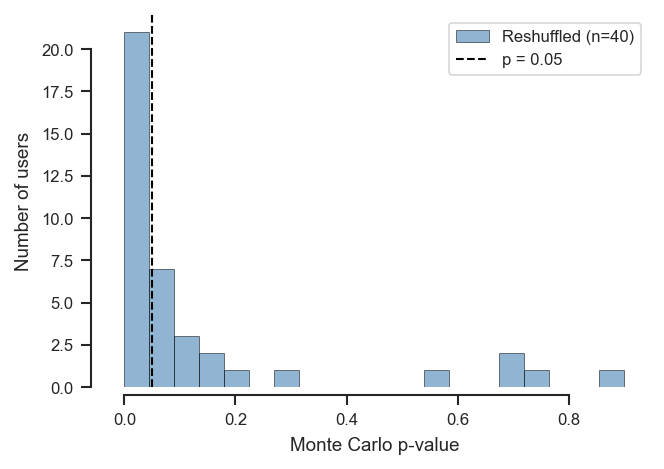

Reshuffled — rejected at p<0.05: 21/40 (52.5%)


In [44]:
# ── Monte Carlo p-value distribution: original vs reshuffled ──────────────────
import seaborn as sns, matplotlib as mpl, matplotlib.pyplot as plt

shuf_pvals = [reshuffle_pvalues[uid] for uid in reshuffle_pvalues if not np.isnan(reshuffle_pvalues[uid])]

# Try to use original p-values if available
orig_pvals_raw = [pvalues_users.get(uid, np.nan) for uid in reshuffle_pvalues]
orig_pvals     = [p for p in orig_pvals_raw if not np.isnan(p)]
have_orig      = len(orig_pvals) > 0

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

ncols = 2 if have_orig else 1
fig, axes = plt.subplots(1, ncols, figsize=(4.5*ncols, 3.2))
if ncols == 1:
    axes = [axes]

# Left: p-value histograms
ax = axes[0]
if have_orig:
    ax.hist(orig_pvals, bins=20, alpha=0.6, color='crimson',   edgecolor='black', lw=0.4,
            label=f'Original (n={len(orig_pvals)})')
ax.hist(shuf_pvals, bins=20, alpha=0.6, color='steelblue', edgecolor='black', lw=0.4,
        label=f'Reshuffled (n={len(shuf_pvals)})')
ax.axvline(0.05, color='black', ls='--', lw=1, label='p = 0.05')
ax.set_xlabel('Monte Carlo p-value')
ax.set_ylabel('Number of users')
ax.legend()
sns.despine(ax=ax, trim=True, offset=4)

# Right: scatter original vs reshuffled (only if both available)
if have_orig:
    ax2 = axes[1]
    pairs = [(pvalues_users.get(uid, np.nan), reshuffle_pvalues[uid])
             for uid in reshuffle_pvalues
             if not np.isnan(pvalues_users.get(uid, np.nan))]
    if pairs:
        ox, sy = zip(*pairs)
        ax2.scatter(ox, sy, alpha=0.65, edgecolors='black', linewidths=0.4, s=30)
        ax2.plot([0,1],[0,1],'k--',lw=1,label='y = x')
        ax2.set_xlabel('p-value (original)')
        ax2.set_ylabel('p-value (reshuffled)')
        ax2.legend()
        sns.despine(ax=ax2, trim=True, offset=4)

fig.tight_layout()
fig.savefig('figures/paper_pvalues_orig_vs_reshuffle.pdf', format='pdf', bbox_inches='tight')
plt.show()

n_shuf_rej = sum(p < 0.05 for p in shuf_pvals)
print(f"Reshuffled — rejected at p<0.05: {n_shuf_rej}/{len(shuf_pvals)} ({100*n_shuf_rej/len(shuf_pvals):.1f}%)")
if have_orig:
    n_orig_rej = sum(p < 0.05 for p in orig_pvals)
    print(f"Original   — rejected at p<0.05: {n_orig_rej}/{len(orig_pvals)} ({100*n_orig_rej/len(orig_pvals):.1f}%)")


In [45]:
# ── Reusable function: CCDF original vs week-reshuffled ───────────────────────
import os, ast
from scipy.stats import ks_2samp
import seaborn as sns, matplotlib as mpl, matplotlib.pyplot as plt

def _parse_array(s):
    cleaned = s.strip().replace('\n', ' ')
    if ',' not in cleaned:
        cleaned = cleaned.replace('[','').replace(']','')
        return np.array([float(x) for x in cleaned.split()])
    return np.array(ast.literal_eval(cleaned))

def run_ccdf_reshuffle_analysis(df_period, reshuffle_csv, label,
                                 min_days=8, n_shuffles=200, seed=42,
                                 save_path=None):
    """
    Plot pooled CCDF (original vs week-reshuffled) for users in reshuffle_csv
    after filtering by min_days of activity.
    """
    rng = np.random.default_rng(seed)

    # Load reshuffle model results to know which users to include
    if not os.path.exists(reshuffle_csv):
        print(f"CSV not found: {reshuffle_csv}")
        return
    saved = pd.read_csv(reshuffle_csv)
    user_ids = saved['user_id'].astype(int).tolist()

    # Apply MIN_DAYS filter
    valid_users = []
    for uid in user_ids:
        udates = pd.to_datetime(
            df_period.loc[df_period['sender_id'] == uid, 'date'], errors='coerce'
        ).dropna()
        if len(udates) >= 2 and (udates.max() - udates.min()).days >= min_days:
            valid_users.append(uid)
    print(f"{label}: {len(valid_users)}/{len(user_ids)} users after MIN_DAYS={min_days} filter")

    # Compute IETs + week reshuffling per user
    all_orig, all_shuf_lists = [], [[] for _ in range(n_shuffles)]
    ks_per_user = {}

    for uid in valid_users:
        udates = pd.to_datetime(
            df_period.loc[df_period['sender_id'] == uid, 'date'], errors='coerce'
        ).dropna().sort_values()
        if len(udates) < 10:
            continue

        ts   = udates.values.astype('int64') / 1e9
        orig = np.diff(np.sort(ts)); orig = orig[orig > 0]
        all_orig.extend(orig.tolist())

        first_monday = udates.iloc[0] - pd.Timedelta(days=udates.iloc[0].weekday())
        wk  = ((udates - first_monday).dt.total_seconds() // (7*86400)).astype(int).values
        wd  = udates.dt.weekday.values
        tod = (udates.dt.hour*3600 + udates.dt.minute*60 + udates.dt.second).values

        shuf_iets_all = []
        for k in range(n_shuffles):
            perm   = rng.permutation(wk)
            new_ts = np.sort(perm*7*86400 + wd*86400 + tod).astype(float)
            s      = np.diff(new_ts); s = s[s > 0]
            all_shuf_lists[k].extend(s.tolist())
            shuf_iets_all.append(s)

        ks_vals  = [ks_2samp(orig, s).statistic for s in shuf_iets_all]
        ks_null  = [ks_2samp(shuf_iets_all[i], shuf_iets_all[i+1]).statistic
                    for i in range(0, n_shuffles-1, 2)]
        pval_ks  = np.mean(np.array(ks_null) >= np.mean(ks_vals))
        ks_per_user[uid] = {'ks_stat': np.mean(ks_vals), 'pval_ks': pval_ks}

    all_orig = np.array(all_orig)
    all_shuf = [np.array(s) for s in all_shuf_lists]
    if len(all_orig) < 10:
        print(f"{label}: not enough data to plot."); return

    # ── CCDF ──────────────────────────────────────────────────────────────────
    lo = np.percentile(all_orig[all_orig>0], 0.5)
    hi = np.percentile(all_orig[all_orig>0], 99.5)
    grid = np.logspace(np.log10(lo), np.log10(hi), 300)

    def ccdf_g(iets, g): return np.array([np.mean(iets > v) for v in g])

    orig_ccdf = ccdf_g(all_orig, grid)
    shuf_mat  = np.array([ccdf_g(s, grid) for s in all_shuf])
    shuf_med  = np.median(shuf_mat, axis=0)
    shuf_p05  = np.percentile(shuf_mat, 5,  axis=0)
    shuf_p95  = np.percentile(shuf_mat, 95, axis=0)

    sns.set_theme(style='ticks', context='paper')
    mpl.rcParams.update({
        'figure.dpi':150,'savefig.dpi':300,'font.size':9,'axes.labelsize':9,
        'axes.titlesize':9,'legend.fontsize':8,'xtick.labelsize':8,'ytick.labelsize':8,
        'axes.spines.top':False,'axes.spines.right':False,
    })

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))

    ax = axes[0]
    ax.fill_between(grid, shuf_p05, shuf_p95, alpha=0.25, color='steelblue', label='Reshuffled 5–95%')
    ax.plot(grid, shuf_med,  color='steelblue', lw=1.4, ls='--', label='Reshuffled median')
    ax.plot(grid, orig_ccdf, color='crimson',   lw=1.8, label='Original')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('IET (s)')
    ax.set_ylabel(r'CCDF  $P(\tau > t)$')
    ax.set_title(f'(a) {label} — pooled CCDF', pad=6)
    ax.legend()
    sns.despine(ax=ax, trim=True, offset=4)

    pvals  = [v['pval_ks'] for v in ks_per_user.values()]
    n_rej  = sum(p < 0.05 for p in pvals)

    ax2 = axes[1]
    ax2.hist(pvals, bins=15, color='steelblue', edgecolor='black', lw=0.4, alpha=0.8)
    ax2.axvline(0.05, color='crimson', ls='--', lw=1.2, label='p = 0.05')
    ax2.set_xlabel('p-value (KS, per user)')
    ax2.set_ylabel('Number of users')
    ax2.set_title(f'(b) {label} — reshuffling test', pad=6)
    ax2.legend()
    sns.despine(ax=ax2, trim=True, offset=4)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"Saved {save_path}")
    plt.show()

    # KS test pooled
    ks_d, ks_p = ks_2samp(all_orig, np.concatenate(all_shuf[:10]))
    print(f"KS test (pooled): D={ks_d:.4f}, p={ks_p:.4e}")
    print(f"Per-user p<0.05: {n_rej}/{len(pvals)} ({100*n_rej/max(len(pvals),1):.1f}%)")


RENFE 2024: 30/30 users after MIN_DAYS=8 filter
Saved figures/paper_ccdf_reshuffle_vagarenfe_2024.pdf


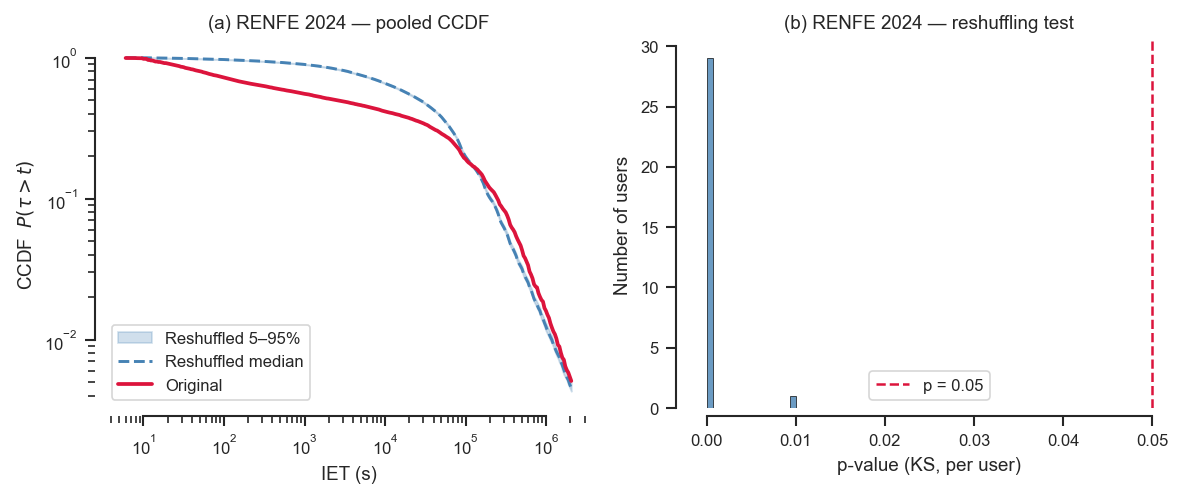

KS test (pooled): D=0.3432, p=0.0000e+00
Per-user p<0.05: 30/30 (100.0%)
RENFE 2026: 26/26 users after MIN_DAYS=8 filter
Saved figures/paper_ccdf_reshuffle_vagarenfe_2026.pdf


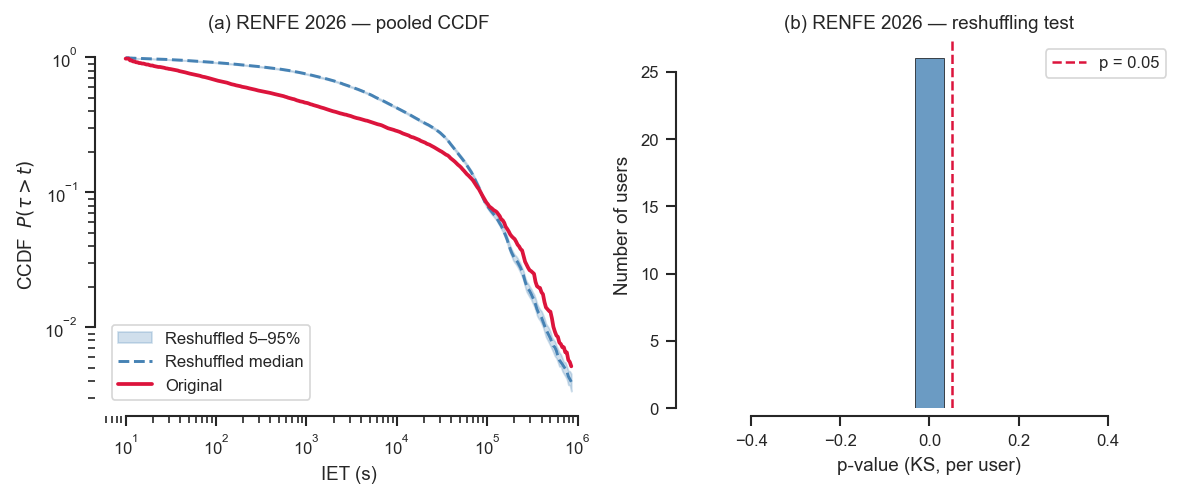

KS test (pooled): D=0.2999, p=0.0000e+00
Per-user p<0.05: 26/26 (100.0%)


In [46]:
# ── CCDF comparison: vagarenfe 2024 and 2026 ──────────────────────────────────
df_vaga = pd.read_json("../../Datasets/vagarenfe.json")
df_vaga['date'] = pd.to_datetime(df_vaga['date'], errors='coerce')
if df_vaga['date'].dt.tz is not None:
    df_vaga['date'] = df_vaga['date'].dt.tz_localize(None)

# ── 2024 ──────────────────────────────────────────────────────────────────────
df_2024 = df_vaga[(df_vaga['date'] >= '2024-01-01') & (df_vaga['date'] < '2025-01-01')].copy()
run_ccdf_reshuffle_analysis(
    df_2024,
    reshuffle_csv='Data/circadian_cycles_vagarenfe_2024_reshuffle_results.csv',
    label='RENFE 2024',
    min_days=MIN_DAYS,
    save_path='figures/paper_ccdf_reshuffle_vagarenfe_2024.pdf',
)

# ── 2026 ──────────────────────────────────────────────────────────────────────
df_2026 = df_vaga[df_vaga['date'] >= '2026-01-15'].copy()
run_ccdf_reshuffle_analysis(
    df_2026,
    reshuffle_csv='Data/circadian_cycles_vagarenfe_2026_reshuffle_results.csv',
    label='RENFE 2026',
    min_days=MIN_DAYS,
    save_path='figures/paper_ccdf_reshuffle_vagarenfe_2026.pdf',
)


In [47]:
df_users.head()


,sender_id,ideology_score,credibility_score
0,1110241832,0,-1
1,5919794964,0,0
2,1093591792,0,0
3,1622328415,0,0
4,6618601093,0,0
